Predicción para acertar la lotería
🌟 Descripción general

Imagina que eres parte del equipo de análisis predictivo de una empresa de juegos de azar.

Tu tarea es desarrollar un sistema capaz de analizar combinaciones de lotería y estimar cuáles tienen más probabilidad de éxito, utilizando inteligencia artificial.

Para ello, crearás un modelo de clasificación con RandomForestClassifier que aprenda de datos históricos simulados, y luego lo aplicarás a nuevas combinaciones para seleccionar las mejores.



📌 Objetivos del proyecto

Desarrollar una aplicación completa compuesta por varias clases, que sea capaz de:

Simular combinaciones de lotería (con 6 números únicos entre 1 y 49).

Generar datos de entrenamiento con etiquetas de "éxito" (1) o "fracaso" (0), simulando que el 10% de las combinaciones históricas fueron ganadoras.

Entrenar un modelo de machine learning para predecir la probabilidad de éxito.

Aplicar el modelo a nuevas combinaciones aleatorias.

Mostrar la mejor combinación según el modelo.

Visualizar en una gráfica las 10 combinaciones con mayor probabilidad de éxito.



🧱 Clases que debes implementar

1.  Clase GeneradorSeries

Responsable de generar combinaciones aleatorias:

Método generar_series(cantidad): genera cantidad combinaciones de 6 números únicos aleatorios entre 1 y 49.

Cada combinación debe estar ordenada para mayor coherencia visual.



2. Clase DatosLoteria

Encargada de crear los datos de entrenamiento:

Método generar_datos_entrenamiento(cantidad=1000): genera un DataFrame con 1000 combinaciones y una columna adicional llamada "Exito" con valores 1 (éxito) o 0 (fracaso), simulando que el 10% de las combinaciones fueron ganadoras.



3. Clase ModeloLoteria

Encargada de construir y entrenar el modelo predictivo:

Entrena un modelo de RandomForestClassifier.

Métodos:

entrenar(X, y): entrena el modelo con los datos escalados.

predecir_probabilidades(X): devuelve las probabilidades de éxito para cada combinación evaluada.



4. Clase VisualizadorResultados

Responsable de mostrar los resultados en un gráfico:

Método graficar_top_combinaciones(df_series, probabilidades, top_n=10):

Muestra un gráfico de barras horizontal con las 10 combinaciones más prometedoras.

Usa matplotlib.pyplot.



5. Clase EjecutarSimulacion

Clase principal que ejecuta todo el flujo del proyecto:

Método ejecutar():

Genera los datos simulados.

Entrena el modelo.

Genera nuevas combinaciones a evaluar.

Predice la probabilidad de éxito.

Muestra por pantalla la mejor combinación encontrada.

Muestra un gráfico con las 10 más prometedoras.



📌 Requisitos técnicos

Utiliza pandas y numpy para manipular datos.

Usa RandomForestClassifier de sklearn.ensemble.

Escala las características numéricas con StandardScaler.

Crea gráficos con matplotlib.pyplot.



🎯 Ejemplo de uso

simulacion = EjecutarSimulacion()

simulacion.ejecutar()


Salida esperada

🎯 Mejor serie encontrada:

Números: [7, 35, 39, 41, 43, 47]

Probabilidad estimada de éxito: 0.4300









Practicar con algoritmos y obtener la serie con mas posiblidades de acertar la lotería

# Solucion:

🎯 Mejor serie encontrada:
Números: [np.int64(3), np.int64(10), np.int64(15), np.int64(27), np.int64(29), np.int64(49)]
Probabilidad estimada de éxito: 0.5300


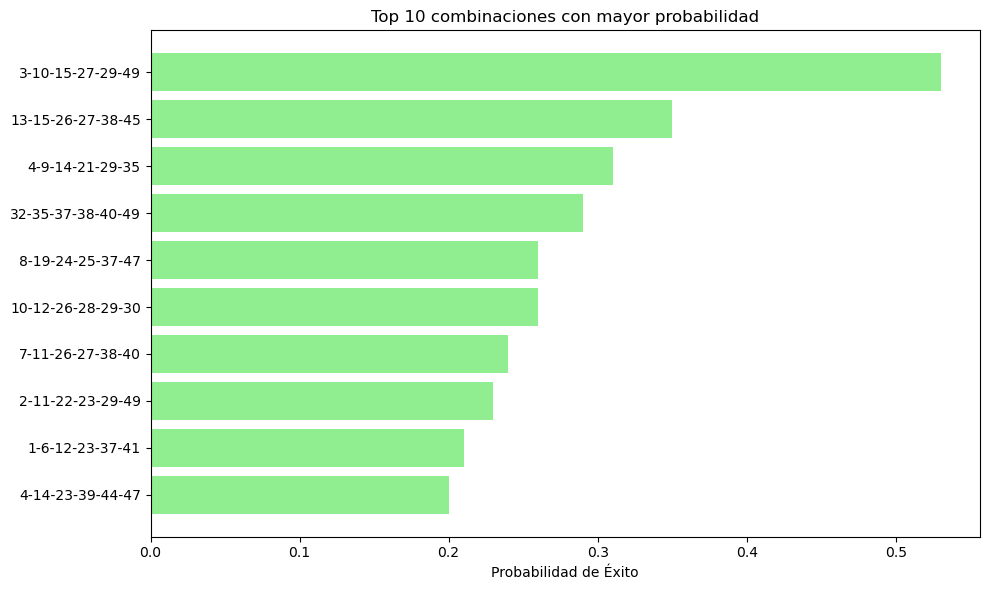

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. Clase GeneradorSeries
# ---------------------------------------------------------
class GeneradorSeries:
    """Genera combinaciones aleatorias de números de lotería."""
    
    def generar_series(self, cantidad):
        # La solución espera que devolvamos una LISTA de arrays/listas, no un DataFrame aún.
        series = []
        for _ in range(cantidad):
            # Generamos 6 números, sin repetición, ordenados
            numeros = sorted(np.random.choice(range(1, 50), 6, replace=False))
            series.append(numeros)
        return series

# ---------------------------------------------------------
# 2. Clase DatosLoteria
# ---------------------------------------------------------
class DatosLoteria:
    """Simula un conjunto de datos con etiquetas de éxito aleatorias."""

    def generar_datos_entrenamiento(self, cantidad=1000):
        generador = GeneradorSeries()
        series = generador.generar_series(cantidad)

        # AQUÍ convertimos la lista a DataFrame y ponemos los nombres de columnas
        cols = [f'Numero_{i+1}' for i in range(6)]
        data = pd.DataFrame(series, columns=cols)
        
        # Generamos la columna Exito (10% de 1s, 90% de 0s)
        # Usamos una semilla local para consistencia si es necesario, 
        # pero la solución usa np.random global.
        data['Exito'] = np.random.choice([0, 1], size=cantidad, p=[0.9, 0.1])
        
        return data

# ---------------------------------------------------------
# 3. Clase ModeloLoteria
# ---------------------------------------------------------
class ModeloLoteria:
    """Entrena un modelo y predice la probabilidad de éxito."""

    def __init__(self):
        self.modelo = RandomForestClassifier(n_estimators=100, random_state=42)
        self.scaler = StandardScaler()

    def entrenar(self, X, y):
        # Es vital escalar antes de entrenar según la solución
        X_scaled = self.scaler.fit_transform(X)
        self.modelo.fit(X_scaled, y)

    def predecir_probabilidades(self, X):
        # Escalamos los nuevos datos con el mismo scaler
        X_scaled = self.scaler.transform(X)
        # Devolvemos solo la columna 1 (probabilidad de éxito)
        return self.modelo.predict_proba(X_scaled)[:, 1]

# ---------------------------------------------------------
# 4. Clase VisualizadorResultados
# ---------------------------------------------------------
class VisualizadorResultados:
    """Muestra un gráfico con las mejores combinaciones según el modelo."""

    def graficar_top_combinaciones(self, df_series, probabilidades, top_n=10):
        # Ordenar índices por probabilidad (de menor a mayor) y tomar los últimos top_n
        top_idx = np.argsort(probabilidades)[-top_n:]
        
        mejores_series = df_series.iloc[top_idx]
        mejores_prob = probabilidades[top_idx]

        # Crear etiqueta tipo "1-2-3-4-5-6" para el gráfico
        etiquetas = mejores_series.astype(str).agg('-'.join, axis=1)

        plt.figure(figsize=(10, 6))
        plt.barh(etiquetas, mejores_prob, color='lightgreen')
        plt.xlabel('Probabilidad de Éxito')
        plt.title('Top 10 combinaciones con mayor probabilidad')
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------
# 5. Clase EjecutarSimulacion
# ---------------------------------------------------------
class EjecutarSimulacion:
    """Clase principal para ejecutar todos los pasos de la simulación."""

    def ejecutar(self):
        # Paso 1: Generar datos simulados de entrenamiento
        datos_simulados = DatosLoteria()
        df_datos = datos_simulados.generar_datos_entrenamiento()
        
        X = df_datos.drop(columns=['Exito'])
        y = df_datos['Exito']

        # Paso 2: Entrenar el modelo
        modelo = ModeloLoteria()
        modelo.entrenar(X, y)

        # Paso 3: Generar nuevas combinaciones a evaluar
        generador = GeneradorSeries()
        # Obtenemos la lista
        nuevas_series_lista = generador.generar_series(100)
        # Convertimos a DataFrame asegurando mismas columnas que X
        df_nuevas = pd.DataFrame(nuevas_series_lista, columns=X.columns)

        # Paso 4: Predecir probabilidades
        probabilidades = modelo.predecir_probabilidades(df_nuevas)

        # Paso 5: Mostrar mejor combinación
        mejor_idx = np.argmax(probabilidades)
        # Accedemos a la lista original para tener los números limpios
        mejor_serie = nuevas_series_lista[mejor_idx]
        
        print("🎯 Mejor serie encontrada:")
        print(f"Números: {mejor_serie}")
        print(f"Probabilidad estimada de éxito: {probabilidades[mejor_idx]:.4f}")

        # Paso 6: Mostrar gráfico
        visualizador = VisualizadorResultados()
        visualizador.graficar_top_combinaciones(df_nuevas, probabilidades)

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
if __name__ == "__main__":
    simulacion = EjecutarSimulacion()
    simulacion.ejecutar()

Casos de prueba

Suspenso: O, Aprobado: 3 de 3 pruebas

test_generar_datos_entrenamiento

test_generar_series

test_modelo_entrenamiento_y_prediccion